In [ ]:
!pip install formulaic

In [ ]:
!pip install linearmodels

In [52]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import  KFold
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator
from linearmodels.iv import IV2SLS
from IPython.display import display
import warnings
from formulaic import Formula
from sklearn.neural_network import MLPRegressor
warnings.simplefilter('ignore')
np.random.seed(1234)

In [ ]:
data = pd.read_stata('/home/onyxia/work/data/dataPrivatePublic.dta')

In [ ]:
#data cleaning
from functions.data_cleaning import clean_data
df = clean_data(data)

## Average treatment effect on the compliers, using DML

In this part, we estimate the causal effect of actual participation (program take-up) using a Double Machine Learning (DML) framework. As the treatment was not randomized, we re-esimate the Local Average Treatment Effect for compliers under a DML framework.

Just like the article at study, we want to evaluate the effect of an intensive caseworking programm on exit to employment. In our setting we had random assignment of two different treatments (one associated to the intensive programm provided by the public service "CVE", the latter by the private sector "OPP"). However, the randomization procedure was not perfect, as we observe a lot of non-compliance in our data.








In [84]:
sample_cveopp = df.loc[df["SAMPLE_CVEOPP"] == 1]

table = pd.crosstab(sample_cveopp["CVE"], sample_cveopp["acceptationCVE_6MOIS"])

print(table)

acceptationCVE_6MOIS    0.0   1.0
CVE                              
0.0                   40425   167
1.0                    2343  1042


In [85]:
sample_cveopp = df.loc[df["SAMPLE_CVEOPP"] == 1]

table = pd.crosstab(sample_cveopp["OPP"], sample_cveopp["acceptationOPP_6MOIS"])

print(table)

acceptationOPP_6MOIS    0.0    1.0
OPP                               
0.0                    7727    223
1.0                   20678  15349


In [86]:
sample_cveopp = df.loc[df["SAMPLE_CVEOPP"] == 1]

table = pd.crosstab(sample_cveopp["OPP"], sample_cveopp["acceptationCVE_6MOIS"])

print(table)

acceptationCVE_6MOIS    0.0   1.0
OPP                              
0.0                    6893  1057
1.0                   35875   152


As we can see, there is non-compliance with the CVE intensive program: some individuals assigned to the control group received the treatment, while some assigned to the treatment did not receive it. We observe a similar pattern for the private program. In addition, there is cross-over between the programs, with some individuals assigned to one program receiving the other instead.

### Comparison between the naive OLS and the LATE results of the paper

First, let us see what result we get when we don't take into account the imbalances between the treatment and control groups. Let's run a naïve regression.

In [93]:
from functions.dml import fmt_coef_and_se
specs = [
    {
        "label": "Within 3 months", "y": "EMPLOI_3MOIS", "d_cve": "acceptationCVE_3MOIS",  "d_opp": "acceptationOPP_3MOIS", "w": "POIDS_PZ_3MOIS",
    },
    {
        "label": "Within 6 months", "y": "EMPLOI_6MOIS", "d_cve": "acceptationCVE_6MOIS","d_opp": "acceptationOPP_6MOIS", "w": "POIDS_PZ_6MOIS",
    },
    {
        "label": "Within 9 months", "y": "EMPLOI_9MOIS", "d_cve": "acceptationCVE_9MOIS", "d_opp": "acceptationOPP_9MOIS", "w": "POIDS_PZ_9MOIS",
    },
    {
        "label": "Within 12 months", "y": "EMPLOI_12MOIS", "d_cve": "acceptationCVE_12MOIS", "d_opp": "acceptationOPP_12MOIS", "w": "POIDS_PZ_12MOIS",
    },
]
X_limited = ["North", "IdF", "salaireG", "duree_listes_horsAR", "Insertion", "Q2", "agegr56", "exper0", "agegr4655", "French", "agegr3645", "Interim", "ce2", "Q3", "EndInterim", "salaireB", "primo", "agegr2635", "nivetude4", "tempcomp", "nivetude3", "salaireD", "EconLayoff", "PersLayoff", "salaireC", "Q1", "African", "salaireE"]

In [63]:
results_rows = []

for spec in specs:

    cols_needed = [spec["y"], spec["d_cve"], spec["d_opp"], spec["w"]]
    temp = sample_cveopp[cols_needed].copy().dropna()

    y = temp[spec["y"]].astype(float)
    X = sm.add_constant(temp[[spec["d_opp"], spec["d_cve"]]].astype(float))
    w = temp[spec["w"]].astype(float)

    model = sm.WLS(y, X, weights=w).fit(cov_type="HC1")

    opp_coef, opp_se = fmt_coef_and_se(model, spec["d_opp"])
    cve_coef, cve_se = fmt_coef_and_se(model, spec["d_cve"])

    results_rows.append([spec["label"], opp_coef, cve_coef])
    results_rows.append(["", opp_se, cve_se])

# sample size line
results_rows.append([
    "Sample size",
    f"{len(sample_cveopp):,}",
    f"{len(sample_cveopp):,}"
])

table = pd.DataFrame(
    results_rows,
    columns=[
        "",
        "Private program (Inflow with UB)",
        "Public program (Inflow with UB)"
    ]
)
display(table)


,,Private program (Inflow with UB),Public program (Inflow with UB)
0,Within 3 months,-0.039***,0.008
1,,(0.005),(0.014)
2,Within 6 months,-0.006,0.071***
3,,(0.007),(0.018)
4,Within 9 months,0.022***,0.075***
5,,(0.008),(0.017)
6,Within 12 months,0.043***,0.056***
7,,(0.008),(0.017)
8,Sample size,"43,977","43,977"


The paper we extend deals with this imbalance problem by running a LATE regression. Here are the results they find.

In [66]:
rows = []

for spec in specs:

    cols = [spec["y"], spec["d_cve"], spec["d_opp"], "CVE", "OPP", spec["w"]]
    temp = sample_cveopp[cols].copy().dropna()

    y = pd.to_numeric(temp[spec["y"]], errors="coerce")
    d_cve = pd.to_numeric(temp[spec["d_cve"]], errors="coerce")
    d_opp = pd.to_numeric(temp[spec["d_opp"]], errors="coerce")
    z = temp[["CVE", "OPP"]].apply(pd.to_numeric, errors="coerce")
    w = pd.to_numeric(temp[spec["w"]], errors="coerce")

    valid = y.notna() & d_cve.notna() & d_opp.notna() & z.notna().all(axis=1) & w.notna()
    y = y.loc[valid]
    d_cve = d_cve.loc[valid]
    d_opp = d_opp.loc[valid]
    z = z.loc[valid]
    w = w.loc[valid]

    # instruments + constante
    Z = sm.add_constant(z, has_constant="add")

    # first stage for CVE treatment
    fs_cve = sm.WLS(d_cve, Z, weights=w).fit()

    # first stage for OPP treatment
    fs_opp = sm.WLS(d_opp, Z, weights=w).fit()

    # fitted endogenous regressors
    d_cve_hat = fs_cve.fittedvalues.rename(spec["d_cve"])
    d_opp_hat = fs_opp.fittedvalues.rename(spec["d_opp"])

    # second stage
    Xhat = pd.concat([d_opp_hat, d_cve_hat], axis=1)
    Xhat = sm.add_constant(Xhat, has_constant="add")

    ss = sm.WLS(y, Xhat, weights=w).fit(cov_type="HC1")

    opp_coef, opp_se = fmt_coef_and_se(ss, spec["d_opp"])
    cve_coef, cve_se = fmt_coef_and_se(ss, spec["d_cve"])

    rows.append([spec["label"], opp_coef, cve_coef])
    rows.append(["", opp_se, cve_se])

    n_used = len(y)

rows.append(["Sample size", f"{n_used:,}", f"{n_used:,}"])

table_iv_manual = pd.DataFrame(
    rows,
    columns=[
        "",
        "Private program\n(Inflow with UB)",
        "Public program\n(Inflow with UB)"
    ]
)

display(table_iv_manual)

,,Private program\n(Inflow with UB),Public program\n(Inflow with UB)
0,Within 3 months,0.021,0.110***
1,,(0.017),(0.033)
2,Within 6 months,0.045**,0.102***
3,,(0.021),(0.038)
4,Within 9 months,0.063***,0.119***
5,,(0.024),(0.037)
6,Within 12 months,0.064***,0.085**
7,,(0.025),(0.038)
8,Sample size,"43,977","43,977"


Same table adding controls.

In [95]:
X_stata = [
    "nivetude1","nivetude3","nivetude4",
    "Cadre","Techn","EmployQ","EmployNQ","OuvrQ",
    "agegr2635","agegr3645","agegr4655","agegr56",
    "femme","marie",
    "onechild","twoormorechild",
    "French","African",
    "IdF","North",
    "ce1","ce2",
    "EconLayoff","PersLayoff","EndCDD","EndInterim",
    "exper0","exper1_5",
    "rsqstat2","rsqstat3",
    "tempcomp","dezus",
    "salaireB","salaireC","salaireD","salaireE","salaireG",
    "primo",
    "Insertion","Interim",
    "Q1","Q2","Q3"
]

iv_results_numeric = []

for spec in specs:

    cols = [
        spec["y"],
        spec["d_cve"],
        spec["d_opp"],
        "CVE",
        "OPP",
        spec["w"]
    ] + X_stata

    temp = df.loc[df["SAMPLE_CVEOPP"] == 1, cols].copy()

    for c in cols:
        temp[c] = pd.to_numeric(temp[c], errors="coerce")

    temp = temp.dropna()

    w_all = temp[spec["w"]]
    temp_valid = temp.loc[w_all > 0].copy()

    y = temp_valid[spec["y"]]
    d_cve = temp_valid[spec["d_cve"]]
    d_opp = temp_valid[spec["d_opp"]]
    z = temp_valid[["CVE", "OPP"]]
    X = temp_valid[X_stata]
    w = temp_valid[spec["w"]]

    # First stage
    Z1 = pd.concat([z, X], axis=1)
    Z1 = sm.add_constant(Z1, has_constant="add")

    fs_cve = sm.WLS(d_cve, Z1, weights=w).fit()
    fs_opp = sm.WLS(d_opp, Z1, weights=w).fit()

    d_cve_hat = fs_cve.fittedvalues.rename(spec["d_cve"])
    d_opp_hat = fs_opp.fittedvalues.rename(spec["d_opp"])

    # Second stage
    X2 = pd.concat([d_cve_hat, d_opp_hat, X], axis=1)
    X2 = sm.add_constant(X2, has_constant="add")

    ss = sm.WLS(y, X2, weights=w).fit(cov_type="HC1")

    iv_results_numeric.append({
        "horizon": spec["label"],
        "months": int(spec["label"].split()[1]),   # works if label = "3 months", etc.
        "coef_CVE_iv": ss.params[spec["d_cve"]],
        "se_CVE_iv": ss.bse[spec["d_cve"]],
        "coef_OPP_iv": ss.params[spec["d_opp"]],
        "se_OPP_iv": ss.bse[spec["d_opp"]],
        "n_iv": len(temp_valid)
    })

iv_summary = pd.DataFrame(iv_results_numeric).sort_values("months")
display(iv_summary)

,horizon,months,coef_CVE_iv,se_CVE_iv,coef_OPP_iv,se_OPP_iv,n_iv
0,Within 3 months,3,0.104153,0.032074,0.016903,0.016607,40939
1,Within 6 months,6,0.090415,0.036951,0.037993,0.020916,37952
2,Within 9 months,9,0.104967,0.036218,0.053408,0.022854,35509
3,Within 12 months,12,0.068465,0.036884,0.051875,0.023893,33500


We see that the results of the naive OLS differ a lot from that of the LATE. What happens when we run a DML analysis ?

## First stage of the DML

+ presentation of the concept
à faire => gérer le pb des valeurs manquantes à chaque stade et rerun tout

In [61]:
#control variables 
X_limited = ["North", "IdF", "salaireG", "duree_listes_horsAR", "Insertion", "Q2", "agegr56", "exper0", "agegr4655", "French", "agegr3645", "Interim", "ce2", "Q3", "EndInterim", "salaireB", "primo", "agegr2635", "nivetude4", "tempcomp", "nivetude3", "salaireD", "EconLayoff", "PersLayoff", "salaireC", "Q1", "African", "salaireE"]

#treatment
d1 = "acceptationCVE_6MOIS"
d2 = "acceptationOPP_6MOIS"

#outcome
y="EMPLOI_6MOIS"

In [62]:
# Regression on baseline controls
X_limited_corrected = [
    "North", "femme", "IdF", "salaireG", "Insertion", "Q2",
     "exper", "French", "age", "Interim", "ce2", "Q3", "EndInterim", "salaireB", "primo", "nivetude4",
    "tempcomp", "nivetude3", "salaireD", "EconLayoff", "PersLayoff",
    "salaireC", "Q1", "African", "salaireE", "duree_listes_horsAR", "marie", "nenf", "ce1",
]

# Ensure 'exper' is numeric before proceeding to prevent ValueError from statsmodels
sample_cveopp["exper"] = pd.to_numeric(sample_cveopp["exper"], errors="coerce")

varlist = [d1] + [d2] + X_limited_corrected
w = sample_cveopp["POIDS_PZ_6MOIS"].astype(float)

# Explicitly convert the DataFrame subset to float to prevent any object dtypes
X_df = sample_cveopp[varlist].astype(float)
X = sm.add_constant(X_df)
y = sample_cveopp["EMPLOI_6MOIS"]

lmC = sm.WLS(y, X, weights=w).fit(cov_type="HC1")
vcC = lmC.cov_params()
print("b_CVE =", lmC.params["acceptationCVE_6MOIS"], "se =", lmC.bse["acceptationCVE_6MOIS"])
print("b_OPP =", lmC.params["acceptationOPP_6MOIS"], "se =", lmC.bse["acceptationOPP_6MOIS"])

b_CVE = 0.05797098559873487 se = 0.014745623746022243
b_OPP = 0.028816756521897836 se = 0.00539588702048443


### I define a transformer that constructs the engineered features for controls

+ justification of the controls (cf. code Salma)

In [73]:
X_limited_corrected = [
    "North", "femme", "IdF", "salaireG", "Insertion", "Q2",
     "exper", "French", "age", "Interim", "ce2", "Q3", "EndInterim", "salaireB", "primo", "nivetude4",
    "tempcomp", "nivetude3", "salaireD", "EconLayoff", "PersLayoff",
    "salaireC", "Q1", "African", "salaireE", "duree_listes_horsAR", "marie", "nenf", "ce1",
]
sample_cveopp["exper"] = pd.to_numeric(sample_cveopp["exper"], errors="coerce")
sample_cveopp[X_limited_corrected].describe()

,North,femme,IdF,salaireG,Insertion,Q2,exper,French,age,Interim,...,EconLayoff,PersLayoff,salaireC,Q1,African,salaireE,duree_listes_horsAR,marie,nenf,ce1
count,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.0,43977.000000,43977.000000,43977.000000,...,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000
mean,0.099757,0.500875,0.806990,0.101599,0.276804,0.353094,6.981672,0.813471,36.714942,0.359961,...,0.124724,0.408645,0.085658,0.171590,0.116970,0.174091,224.029373,0.462128,0.902244,0.229597
std,0.299679,0.500005,0.394665,0.302123,0.447424,0.477937,7.947843,0.389538,10.503770,0.479994,...,0.330410,0.491589,0.279862,0.377028,0.321388,0.379192,120.972954,0.498569,1.247945,0.420579
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,17.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-87.400002,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.0,1.000000,28.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,116.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,4.0,1.000000,35.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,237.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,10.0,1.000000,45.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,353.000000,1.000000,2.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,42.0,1.000000,65.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,365.000000,1.000000,9.000000,1.000000


In [74]:
class FormulaTransformer(TransformerMixin, BaseEstimator):

    def __init__(self, formula, array=False):
        self.formula = formula
        self.array = array

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = Formula(self.formula).get_model_matrix(X)
        if self.array:
            return df.values
        return df

In [75]:
transformer = FormulaTransformer(
    "0 "
    "+ poly(age, degree=3, raw=True)"
    "+ poly(exper, degree=3, raw=True)"
    "+ poly(duree_listes_horsAR, degree=3, raw=True)"
    "+ poly(nenf, degree=2, raw=True)"
    "+ North + IdF + French + African + femme + marie"
    "+ Interim + EndInterim + tempcomp"
    "+ ce1 + ce2"
    "+ nivetude3 + nivetude4"
    "+ salaireB + salaireC + salaireD + salaireE"
    "+ Q1 + Q2 + Q3"
    "+ EconLayoff + PersLayoff"
    "+ primo + Insertion"
    "+ age:exper"
    "+ femme:nenf"
    "+ femme:exper"
    "+ duree_listes_horsAR:exper"
    "+ French:IdF"
    "+ African:IdF"
    "+ nivetude3:exper"
    "+ nivetude4:exper",
    array=False
)

In [76]:
transformer.fit_transform(sample_cveopp[X_limited_corrected]).describe()

,"poly(age, degree=3, raw=True)[0]","poly(age, degree=3, raw=True)[1]","poly(age, degree=3, raw=True)[2]","poly(exper, degree=3, raw=True)[0]","poly(exper, degree=3, raw=True)[1]","poly(exper, degree=3, raw=True)[2]","poly(duree_listes_horsAR, degree=3, raw=True)[0]","poly(duree_listes_horsAR, degree=3, raw=True)[1]","poly(duree_listes_horsAR, degree=3, raw=True)[2]","poly(nenf, degree=2, raw=True)[0]",...,primo,Insertion,age:exper,femme:nenf,femme:exper,duree_listes_horsAR:exper,French:IdF,African:IdF,nivetude3:exper,nivetude4:exper
count,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000,4.397700e+04,43977.000000,...,43977.000000,43977.000000,43977.000000,43977.000000,43977.00000,43977.000000,43977.000000,43977.000000,43977.000000,43977.000000
mean,36.714942,1458.313641,3164.318917,6.981672,111.910521,2497.422766,224.029373,64823.277344,2.057602e+07,0.902244,...,0.620529,0.276804,306.560998,0.484458,3.26357,1588.794993,0.635946,0.106715,2.222548,1.627578
std,10.503770,815.302898,19624.858003,7.947843,231.196534,7319.914763,120.972954,51300.066406,1.957052e+07,1.247945,...,0.485261,0.447424,416.496169,0.984388,6.24282,2229.955216,0.481169,0.308754,5.770111,5.206886
min,17.000000,289.000000,-32768.000000,0.000000,0.000000,0.000000,-87.400002,0.000000,-6.676277e+05,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,-1591.199974,0.000000,0.000000,0.000000,0.000000
25%,28.000000,784.000000,-14883.000000,1.000000,1.000000,1.000000,116.000000,13456.000000,1.560896e+06,0.000000,...,0.000000,0.000000,42.000000,0.000000,0.00000,167.999992,0.000000,0.000000,0.000000,0.000000
50%,35.000000,1225.000000,9261.000000,4.000000,16.000000,64.000000,237.000000,56169.000000,1.331205e+07,0.000000,...,1.000000,0.000000,135.000000,0.000000,0.00000,714.000000,1.000000,0.000000,0.000000,0.000000
75%,45.000000,2025.000000,19648.000000,10.000000,100.000000,1000.000000,353.000000,124609.000000,4.398698e+07,2.000000,...,1.000000,1.000000,396.000000,1.000000,4.00000,2072.000000,1.000000,0.000000,1.000000,0.000000
max,65.000000,4225.000000,31800.000000,42.000000,1764.000000,74088.000000,365.000000,133225.000000,4.862712e+07,9.000000,...,1.000000,1.000000,2480.000000,9.000000,42.00000,14965.000000,1.000000,1.000000,42.000000,42.000000


### Estimating the ATE

In [77]:
y = sample_cveopp["EMPLOI_6MOIS"].values
D1 = sample_cveopp['acceptationCVE_6MOIS'].values
D2 = sample_cveopp['acceptationOPP_6MOIS'].values
X = sample_cveopp[X_limited_corrected]

In [78]:
from functions.dml import dml_two_treatments
from functions.dml import summary_two_treatments
from functions.dml import run_dml_grid
from functions.dml import select_best_learners 

### Learners of E[Y|X], E[D1|X] and E[D2|X]

In [79]:
cv = KFold(n_splits=5, shuffle=True, random_state=123)

In [80]:
learners_d = {

    "Logit": make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv, penalty='l2', solver='liblinear')), "RF": make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001)), "Tree": make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001)),  "GBF": make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5)),  "MLP": make_pipeline(StandardScaler(),
                       MLPRegressor(hidden_layer_sizes=(50, 50, 50, 50),
                                    activation='relu',
                                    solver='adam',
                                    alpha=0.0001,
                                    batch_size=200,
                                    learning_rate='constant',
                                    learning_rate_init=0.001,
                                    max_iter=200,
                                    shuffle=True,
                                    random_state=None,
                                    tol=1e-4,
                                    verbose=False,
                                    warm_start=False,
                                    momentum=0.9,
                                    nesterovs_momentum=True,
                                    early_stopping=True,
                                    validation_fraction=0.2,
                                    beta_1=0.9,
                                    beta_2=0.999,
                                    epsilon=1e-08,
                                    n_iter_no_change=10)
                       )
}

In [81]:
learners_y = {
    "Logit": make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv, penalty='l2', solver='liblinear')),

    "RF":  make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001)),

    "Tree": make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001)),

    "GBF": make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5)),

    "MLP": make_pipeline(StandardScaler(),
                       MLPRegressor(hidden_layer_sizes=(50, 50, 50, 50),
                                    activation='relu',
                                    solver='adam',
                                    alpha=0.0001,
                                    batch_size=200,
                                    learning_rate='constant',
                                    learning_rate_init=0.001,
                                    max_iter=200,
                                    shuffle=True,
                                    random_state=None,
                                    tol=1e-4,
                                    verbose=False,
                                    warm_start=False,
                                    momentum=0.9,
                                    nesterovs_momentum=True,
                                    early_stopping=True,
                                    validation_fraction=0.2,
                                    beta_1=0.9,
                                    beta_2=0.999,
                                    epsilon=1e-08,
                                    n_iter_no_change=10)
                       )
}

### Estimate all combinations and compute goodness of fit

In [ ]:
#this cell is long to charge 9 minutes on my computer (so e have saved he results in a database, please go to the next code cell)
#results_EMPLOI_6MOIS = run_dml_grid(
#    X=X,
#    y=y,
#    D1=D1,
#    D2=D2,
#    learners_y=learners_y,
#    learners_d=learners_d
#)

#results_EMPLOI_6MOIS = results_EMPLOI_6MOIS.sort_values(
#    by=["rmse y", "rmse D1", "rmse D2"],
#    ascending=True
#)

#results_EMPLOI_6MOIS.to_csv('/home/onyxia/work/data/learners_DML_EMPLOI6MOIS.csv', index=False) #on enregistre la base


In [82]:
#All learners 
results_EMPLOI_6MOIS =pd.read_csv('/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI6MOIS.csv')

print("\nGoodness of fit and DML results for all combinations:\n") #on affiche les résultats

print(
    results_EMPLOI_6MOIS[
        [
            "learner_y",
            "learner_d",
            "treatment",
            "rmse y",
            "rmse D1",
            "rmse D2",
            "estimate",
            "stderr"
        ]
    ].to_string(index=False)
)


Goodness of fit and DML results for all combinations:

learner_y learner_d   treatment   rmse y  rmse D1  rmse D2  estimate   stderr
      GBF       GBF CVE_treated 0.313031 0.163363 0.463424  0.088569 0.009201
      GBF       GBF OPP_treated 0.313031 0.163363 0.463424  0.039566 0.003243
      GBF     Logit CVE_treated 0.313056 0.306316 0.464799  0.087723 0.009211
      GBF     Logit OPP_treated 0.313056 0.306316 0.464799  0.038027 0.003235
      GBF      Tree CVE_treated 0.313082 0.163514 0.470245  0.089502 0.009186
      GBF      Tree OPP_treated 0.313082 0.163514 0.470245  0.040945 0.003194
      GBF       MLP CVE_treated 0.313135 0.164999 0.467960  0.086219 0.009110
      GBF       MLP OPP_treated 0.313135 0.164999 0.467960  0.036997 0.003213
      GBF        RF CVE_treated 0.313234 0.163514 0.470883  0.089425 0.009189
      GBF        RF OPP_treated 0.313234 0.163514 0.470883  0.039993 0.003191
    Logit       GBF CVE_treated 0.317424 0.163416 0.463530  0.090346 0.009326
    Logi

### Choose the best learner and compute the final estimation with the best combination

In [21]:
best_learner_y, best_learner_d1, best_learner_d2 = select_best_learners(results_EMPLOI_6MOIS)

Best learner for Y:
learner_y   rmse y
      GBF 0.313108
    Logit 0.317424
     Tree 0.319182
       RF 0.319450
      MLP 0.321071

Best learner for D1:
learner_d  rmse D1
      GBF 0.163339
     Tree 0.163514
       RF 0.163514
      MLP 0.164964
    Logit 0.306316

Best learner for D2:
learner_d  rmse D2
      GBF 0.463499
    Logit 0.464799
      MLP 0.468207
     Tree 0.470242
       RF 0.470959

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF


In [22]:
dml_best = dml_two_treatments(
    X=X,
    D1=D1,
    D2=D2,
    y=y,
    modely=learners_y[best_learner_y],
    modeld1=learners_d[best_learner_d1],
    modeld2=learners_d[best_learner_d2],
    nfolds=5,
    classifier_y=True,
    classifier_d1=True,
    classifier_d2=True,
    cluster=False,
    progress=True
)

(
    point1, point2, stderr1, stderr2,
    yhat, D1hat, D2hat,
    resy, resD1, resD2,
    epsilon
) = dml_best

DML steps: 100%|██████████| 5/5 [00:22<00:00,  4.51s/it]


In [57]:
import importlib
import functions.dml

importlib.reload(functions.dml)

<module 'functions.dml' from '/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/functions/dml.py'>

In [83]:
from functions.dml import make_dml_final_table
final_table = make_dml_final_table(
    point1, point2, stderr1, stderr2,
    resy, resD1, resD2, epsilon,
    name1="CVE_treated",
    name2="OPP_treated",
    learner_y=best_learner_y,
    learner_d1=best_learner_d1,
    learner_d2=best_learner_d2,
    n=len(y)
)

print("\nFinal DML results\n")
print(final_table.to_string(index=False))


Final DML results

  treatment  estimate  std.error         z  p.value  ci.lower  ci.upper   rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.088879   0.009210  9.649954      0.0  0.070827  0.106931 0.313121  0.16326 0.463458    0.312368       GBF        GBF        GBF 43977
OPP_treated  0.039362   0.003244 12.131903      0.0  0.033002  0.045721 0.313121  0.16326 0.463458    0.312368       GBF        GBF        GBF 43977


### Do the procedure for the variables EMPLOI_3MOIS, EMPLOI_9MOIS and EMPLOI_12MOIS to get the evolution of the causal effect

The results are really close to that to the LATE estimation ! This means that the DML procedure do work !

In [90]:
results_EMPLOI_3MOIS.to_csv('/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI3MOIS.csv')

In [91]:
# =========================================
# 1) Define the specifications
# =========================================
specs = [
    {
        "label": "3 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI3MOIS.csv",
        "y_var": "EMPLOI_3MOIS",
        "d1_var": "acceptationCVE_3MOIS",
        "d2_var": "acceptationOPP_3MOIS",
    },
    {
        "label": "6 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI6MOIS.csv",
        "y_var": "EMPLOI_6MOIS",
        "d1_var": "acceptationCVE_6MOIS",
        "d2_var": "acceptationOPP_6MOIS",
    },
    {
        "label": "9 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI9MOIS.csv",
        "y_var": "EMPLOI_9MOIS",
        "d1_var": "acceptationCVE_9MOIS",
        "d2_var": "acceptationOPP_9MOIS",
    },
    {
        "label": "12 months",
        "results_file": "/home/onyxia/work/Who-When-and-Which-Program-Optimal-Allocation-of-Job-Search-Counseling/data/learners_DML_EMPLOI12MOIS.csv",
        "y_var": "EMPLOI_12MOIS",
        "d1_var": "acceptationCVE_12MOIS",
        "d2_var": "acceptationOPP_12MOIS",
    },
]

# =========================================
# 2) Store all results here
# =========================================
all_results = []
all_final_tables = {}

# =========================================
# 3) Loop over all horizons
# =========================================
for spec in specs:
    print(f"\n=== Running DML for {spec['label']} ===\n")

    # Load the table of learner performances
    results_dml = pd.read_csv(spec["results_file"])

    # Select best learners
    best_learner_y, best_learner_d1, best_learner_d2 = select_best_learners(results_dml)

    print("Selected learners:")
    print(" best_learner_y  =", best_learner_y)
    print(" best_learner_d1 =", best_learner_d1)
    print(" best_learner_d2 =", best_learner_d2)

    # Build variables for this horizon
    y = sample_cveopp[spec["y_var"]]
    D1 = sample_cveopp[spec["d1_var"]]
    D2 = sample_cveopp[spec["d2_var"]]

    # Optional: restrict to complete cases
    temp = pd.concat([X, y, D1, D2], axis=1).dropna()
    X_use = temp[X.columns]
    y_use = temp[spec["y_var"]]
    D1_use = temp[spec["d1_var"]]
    D2_use = temp[spec["d2_var"]]

    # Run DML with the selected learners
    dml_best = dml_two_treatments(
        X=X_use,
        D1=D1_use,
        D2=D2_use,
        y=y_use,
        modely=learners_y[best_learner_y],
        modeld1=learners_d[best_learner_d1],
        modeld2=learners_d[best_learner_d2],
        nfolds=5,
        classifier_y=True,
        classifier_d1=True,
        classifier_d2=True,
        cluster=False,
        progress=True
    )

    (
        point1, point2, stderr1, stderr2,
        yhat, D1hat, D2hat,
        resy, resD1, resD2,
        epsilon
    ) = dml_best

    # Detailed final table for this horizon
    final_table = make_dml_final_table(
        point1, point2, stderr1, stderr2,
        resy, resD1, resD2, epsilon,
        name1="CVE_treated",
        name2="OPP_treated",
        learner_y=best_learner_y,
        learner_d1=best_learner_d1,
        learner_d2=best_learner_d2,
        n=len(y_use)
    )

    all_final_tables[spec["label"]] = final_table

    print("\nFinal DML results")
    print(final_table.to_string(index=False))

    # Save compact summary row
    all_results.append({
        "horizon": spec["label"],
        "outcome": spec["y_var"],
        "best_learner_y": best_learner_y,
        "best_learner_d1": best_learner_d1,
        "best_learner_d2": best_learner_d2,
        "coef_CVE": point1,
        "se_CVE": stderr1,
        "coef_OPP": point2,
        "se_OPP": stderr2,
        "n": len(y_use),
    })

# =========================================
# 4) Final summary database
# =========================================
summary_table = pd.DataFrame(all_results)

print("\n=== Summary table across all horizons ===\n")
display(summary_table)


=== Running DML for 3 months ===

Best learner for Y:
learner_y   rmse y
      GBF 0.241516
     Tree 0.245655
    Logit 0.247076
       RF 0.247817
      MLP 0.250243

Best learner for D1:
learner_d  rmse D1
      GBF 0.156158
     Tree 0.156307
       RF 0.156307
      MLP 0.157900
    Logit 0.303760

Best learner for D2:
learner_d  rmse D2
      GBF 0.461472
    Logit 0.462438
      MLP 0.466043
     Tree 0.468016
       RF 0.468785

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF
Selected learners:
 best_learner_y  = GBF
 best_learner_d1 = GBF
 best_learner_d2 = GBF


DML steps:   0%|          | 0/5 [00:00<?, ?it/s]

DML steps: 100%|██████████| 5/5 [00:23<00:00,  4.69s/it]



Final DML results
  treatment  estimate  std.error        z  p.value  ci.lower  ci.upper   rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.041360   0.007429 5.567736      0.0  0.026800  0.055920 0.241383 0.156122 0.461686     0.24123       GBF        GBF        GBF 43977
OPP_treated  0.014206   0.002512 5.655154      0.0  0.009282  0.019129 0.241383 0.156122 0.461686     0.24123       GBF        GBF        GBF 43977

=== Running DML for 6 months ===

Best learner for Y:
learner_y   rmse y
      GBF 0.313108
    Logit 0.317424
     Tree 0.319182
       RF 0.319450
      MLP 0.321071

Best learner for D1:
learner_d  rmse D1
      GBF 0.163339
     Tree 0.163514
       RF 0.163514
      MLP 0.164964
    Logit 0.306316

Best learner for D2:
learner_d  rmse D2
      GBF 0.463499
    Logit 0.464799
      MLP 0.468207
     Tree 0.470242
       RF 0.470959

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF
Selected learners:
 best_learner_y  = GBF
 best_l

DML steps: 100%|██████████| 5/5 [00:16<00:00,  3.23s/it]


...

DML steps: 100%|██████████| 5/5 [00:17<00:00,  3.54s/it]



Final DML results
  treatment  estimate  std.error         z  p.value  ci.lower  ci.upper  rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.121302   0.009776 12.408271      0.0  0.102142  0.140463 0.35284 0.173444 0.464211    0.351676       GBF        GBF        GBF 43977
OPP_treated  0.049042   0.003653 13.426711      0.0  0.041883  0.056202 0.35284 0.173444 0.464211    0.351676       GBF        GBF        GBF 43977

=== Running DML for 12 months ===

Best learner for Y:
learner_y   rmse y
      GBF 0.381389
    Logit 0.384556
       RF 0.387330
      MLP 0.388324
     Tree 0.388639

Best learner for D1:
learner_d  rmse D1
      GBF 0.178304
     Tree 0.178627
       RF 0.178627
      MLP 0.180091
    Logit 0.311959

Best learner for D2:
learner_d  rmse D2
      GBF 0.464413
    Logit 0.465731
      MLP 0.468759
     Tree 0.470854
       RF 0.471758

Selected learners:
Y  = GBF
D1 = GBF
D2 = GBF
Selected learners:
 best_learner_y  = GBF
 best_

DML steps: 100%|██████████| 5/5 [00:17<00:00,  3.55s/it]


Final DML results
  treatment  estimate  std.error         z  p.value  ci.lower  ci.upper  rmse_y  rmse_d1  rmse_d2  rmse_final learner_y learner_d1 learner_d2     n
CVE_treated  0.119204   0.010285 11.590263      0.0  0.099046  0.139363 0.38137 0.178324 0.464433    0.380114       GBF        GBF        GBF 43977
OPP_treated  0.055840   0.003949 14.140340      0.0  0.048100  0.063580 0.38137 0.178324 0.464433    0.380114       GBF        GBF        GBF 43977

=== Summary table across all horizons ===



,horizon,outcome,best_learner_y,best_learner_d1,best_learner_d2,coef_CVE,se_CVE,coef_OPP,se_OPP,n
0,3 months,EMPLOI_3MOIS,GBF,GBF,GBF,0.041360,0.007429,0.014206,0.002512,43977
1,6 months,EMPLOI_6MOIS,GBF,GBF,GBF,0.088907,0.009205,0.039486,0.003244,43977
2,9 months,EMPLOI_9MOIS,GBF,GBF,GBF,0.121302,0.009776,0.049042,0.003653,43977
3,12 months,EMPLOI_12MOIS,GBF,GBF,GBF,0.119204,0.010285,0.055840,0.003949,43977


In [96]:
dml_summary = summary_table.copy()

dml_summary["months"] = dml_summary["horizon"].str.extract(r"(\d+)").astype(int)

dml_summary = dml_summary.rename(columns={
    "coef_CVE": "coef_CVE_dml",
    "se_CVE": "se_CVE_dml",
    "coef_OPP": "coef_OPP_dml",
    "se_OPP": "se_OPP_dml"
})

dml_summary = dml_summary.sort_values("months")
display(dml_summary)

,horizon,outcome,best_learner_y,best_learner_d1,best_learner_d2,coef_CVE_dml,se_CVE_dml,coef_OPP_dml,se_OPP_dml,n,months
0,3 months,EMPLOI_3MOIS,GBF,GBF,GBF,0.041360,0.007429,0.014206,0.002512,43977,3
1,6 months,EMPLOI_6MOIS,GBF,GBF,GBF,0.088907,0.009205,0.039486,0.003244,43977,6
2,9 months,EMPLOI_9MOIS,GBF,GBF,GBF,0.121302,0.009776,0.049042,0.003653,43977,9
3,12 months,EMPLOI_12MOIS,GBF,GBF,GBF,0.119204,0.010285,0.055840,0.003949,43977,12


In [98]:
plot_df = pd.merge(
    dml_summary[["months", "coef_CVE_dml", "se_CVE_dml", "coef_OPP_dml", "se_OPP_dml"]],
    iv_summary[["months", "coef_CVE_iv", "se_CVE_iv", "coef_OPP_iv", "se_OPP_iv"]],
    on="months",
    how="inner"
).sort_values("months")

display(plot_df)

,months,coef_CVE_dml,se_CVE_dml,coef_OPP_dml,se_OPP_dml,coef_CVE_iv,se_CVE_iv,coef_OPP_iv,se_OPP_iv
0,3,0.041360,0.007429,0.014206,0.002512,0.104153,0.032074,0.016903,0.016607
1,6,0.088907,0.009205,0.039486,0.003244,0.090415,0.036951,0.037993,0.020916
2,9,0.121302,0.009776,0.049042,0.003653,0.104967,0.036218,0.053408,0.022854
3,12,0.119204,0.010285,0.055840,0.003949,0.068465,0.036884,0.051875,0.023893


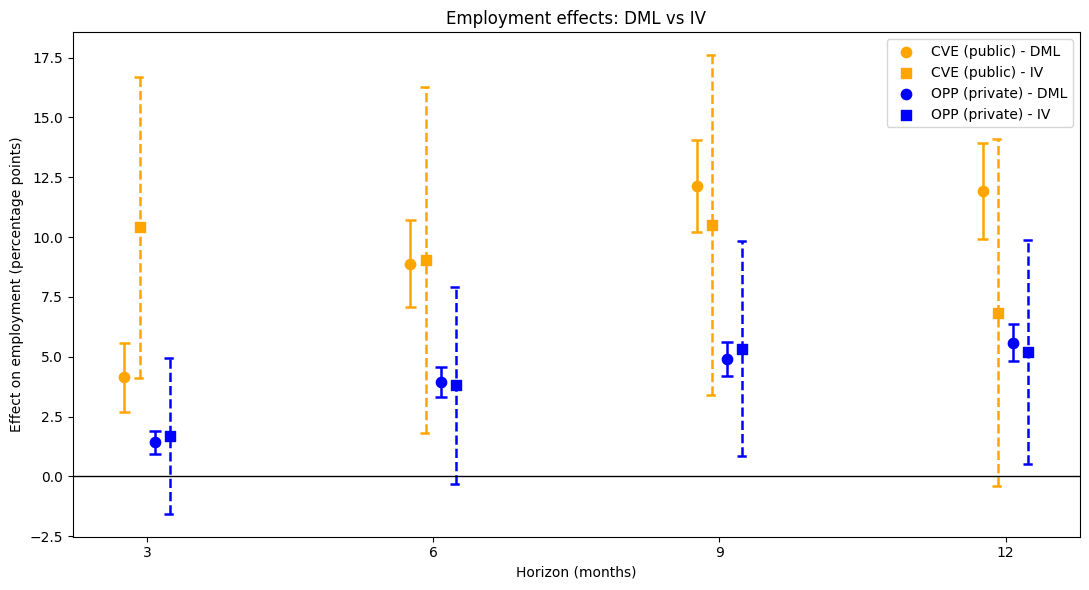

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# x positions
x = plot_df["months"].to_numpy()

# coefficients en points de pourcentage
cve_dml = 100 * plot_df["coef_CVE_dml"].to_numpy()
cve_dml_se = 100 * plot_df["se_CVE_dml"].to_numpy()

cve_iv = 100 * plot_df["coef_CVE_iv"].to_numpy()
cve_iv_se = 100 * plot_df["se_CVE_iv"].to_numpy()

opp_dml = 100 * plot_df["coef_OPP_dml"].to_numpy()
opp_dml_se = 100 * plot_df["se_OPP_dml"].to_numpy()

opp_iv = 100 * plot_df["coef_OPP_iv"].to_numpy()
opp_iv_se = 100 * plot_df["se_OPP_iv"].to_numpy()

# positions côte à côte
offset = 0.16
x_cve_dml = x - 1.5 * offset
x_cve_iv  = x - 0.5 * offset
x_opp_dml = x + 0.5 * offset
x_opp_iv  = x + 1.5 * offset

# style des IC
z = 1.96
cap_width = 0.06

fig, ax = plt.subplots(figsize=(11, 6))

def draw_errorbars(ax, xvals, yvals, ses, color, linestyle, marker, label):
    lower = yvals - z * ses
    upper = yvals + z * ses

    # ligne verticale
    ax.vlines(xvals, lower, upper, colors=color, linestyles=linestyle, linewidth=1.8)

    # petits caps horizontaux
    for xi, lo, up in zip(xvals, lower, upper):
        ax.hlines(lo, xi - cap_width, xi + cap_width, colors=color, linestyles=linestyle, linewidth=1.8)
        ax.hlines(up, xi - cap_width, xi + cap_width, colors=color, linestyles=linestyle, linewidth=1.8)

    # point estimate
    ax.scatter(xvals, yvals, color=color, marker=marker, s=55, label=label, zorder=3)

# CVE = orange
draw_errorbars(
    ax, x_cve_dml, cve_dml, cve_dml_se,
    color="orange", linestyle="solid", marker="o",
    label="CVE (public) - DML"
)

draw_errorbars(
    ax, x_cve_iv, cve_iv, cve_iv_se,
    color="orange", linestyle="dashed", marker="s",
    label="CVE (public) - IV"
)

# OPP = bleu
draw_errorbars(
    ax, x_opp_dml, opp_dml, opp_dml_se,
    color="blue", linestyle="solid", marker="o",
    label="OPP (private) - DML"
)

draw_errorbars(
    ax, x_opp_iv, opp_iv, opp_iv_se,
    color="blue", linestyle="dashed", marker="s",
    label="OPP (private) - IV"
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(x.astype(int))
ax.set_xlabel("Horizon (months)")
ax.set_ylabel("Effect on employment (percentage points)")
ax.set_title("Employment effects: DML vs IV")
ax.legend()
plt.tight_layout()
plt.show()